In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression


In [8]:
DATA_PATH="../data/raw/WA_fn-UseC_-Telco-Customer-Churn.csv"

In [9]:
df=pd.read_csv(DATA_PATH)

In [10]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [11]:
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce')

In [12]:
df['TotalCharges'].dtype

dtype('float64')

In [13]:
X=df.drop(columns=['customerID','Churn'])
y=df['Churn'].map({"No":0,"Yes":1})

In [14]:
numeric_features=X.select_dtypes(include=['int64','float64']).columns

categorical_features=X.select_dtypes(include=['str']).columns

In [15]:
numeric_features

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='str')

In [16]:
categorical_features

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='str')

In [17]:
print("Numerical Features: ")
print(numeric_features.tolist())
print("\nCategorical Features: ")
print(categorical_features.tolist())

Numerical Features: 
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical Features: 
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [18]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [19]:
print("Training distribution: ")
print(y_train.value_counts(normalize=True))
print("\nTesting distribution: ")
print(y_test.value_counts(normalize=True))

Training distribution: 
Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64

Testing distribution: 
Churn
0    0.734564
1    0.265436
Name: proportion, dtype: float64


In [21]:
numeric_pipeline=Pipeline([
    ("imputer",SimpleImputer(strategy='median')),
    ("scaler",StandardScaler())
])

In [22]:
categorical_pipeline=Pipeline([
    ("imputer",SimpleImputer(strategy='most_frequent')),
    ("encoder",OneHotEncoder(handle_unknown='ignore'))
])

In [23]:
preprocessor=ColumnTransformer([
    ("num",numeric_pipeline,numeric_features),
    ("cat",categorical_pipeline,categorical_features)
])

In [24]:
logistic_model=LogisticRegression(max_iter=1000)

In [28]:
baseline_pipeline=Pipeline([
    ("preprocessor",preprocessor),
    ("model",logistic_model)
])

In [29]:
baseline_pipeline.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['gender','SeniorCitizen','Partner',...,'PaymentMethod','MonthlyCharges', 'TotalCharges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='pa

In [31]:
y_pred=baseline_pipeline.predict(X_test)

In [32]:
baseline_pipeline.predict_proba(X_test)[:5]

array([[0.95470613, 0.04529387],
       [0.31558874, 0.68441126],
       [0.94127926, 0.05872074],
       [0.59829576, 0.40170424],
       [0.97845228, 0.02154772]])

In [33]:
y_prob=baseline_pipeline.predict_proba(X_test)[:,1]

In [34]:
prediction_results=pd.DataFrame({
    "Actual":y_test.values,
    "Predicted":y_pred,
    "Churn_Probability":y_prob
})

In [35]:
prediction_results.head(10)

,Actual,Predicted,Churn_Probability
0,0,0,0.045294
1,0,1,0.684411
2,0,0,0.058721
3,0,0,0.401704
4,0,0,0.021548
5,0,1,0.603935
6,0,0,0.449225
7,0,0,0.130055
8,0,0,0.002881
9,1,0,0.395179


In [36]:
accuracy=accuracy_score(y_test,y_pred)

print("Accuracy: ",accuracy)

Accuracy:  0.8055358410220014


In [37]:
cm=confusion_matrix(y_test,y_pred)
cm

array([[926, 109],
       [165, 209]])

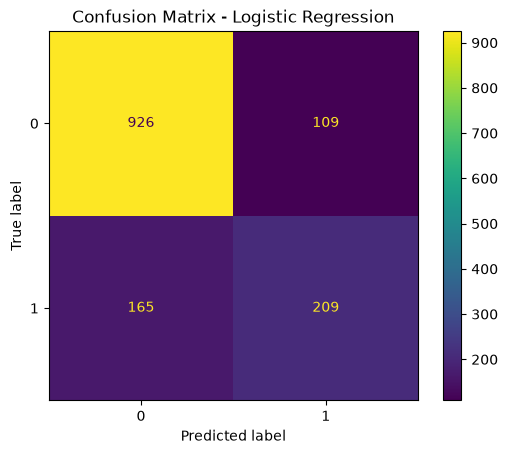

In [39]:
ConfusionMatrixDisplay.from_predictions(y_test,y_pred)

plt.title("Confusion Matrix - Logistic Regression")
plt.show()



In [40]:
precision=precision_score(y_test,y_pred)
precision

0.6572327044025157

In [42]:
recall=recall_score(y_test,y_pred)
recall

0.5588235294117647

In [43]:
f1=f1_score(y_test,y_pred)

print("F1 Score: ",f1)

F1 Score:  0.6040462427745664


In [44]:
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 0.8055
Precision: 0.6572
Recall   : 0.5588
F1 Score : 0.6040


In [46]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "No Churn",
            "Churn"
        ]
    )
)

              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1035
       Churn       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [47]:
roc_auc=roc_auc_score(y_test,y_prob)

print("ROC-AUC : ",roc_auc)

ROC-AUC :  0.8418610659019866


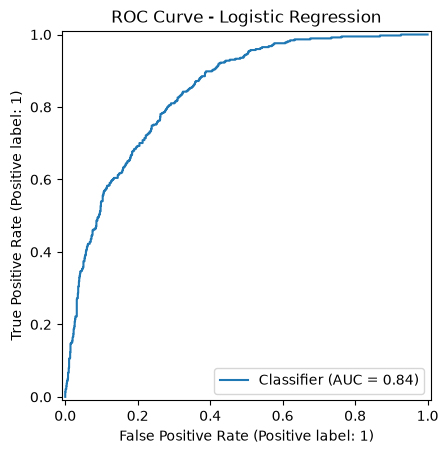

In [51]:
RocCurveDisplay.from_predictions(y_test,y_prob)

plt.title('ROC Curve - Logistic Regression')
plt.show()

In [56]:
baseline_results=pd.DataFrame({
    "Model":["Logistic Regression"],
    "Accuracy":accuracy,
    "Precision":precision,
    "Recall":recall,
    "F1":f1,
    "ROC_AUC":roc_auc
})

baseline_results

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.805536,0.657233,0.558824,0.604046,0.841861
